# Captioning the Capital: Multimodal Topic Modeling and the National Photo Company Collection

### Nabeel Siddiqui
Susquehanna University

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
© Nabeel Siddiqui. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


This article uses vision-language models and neural topic modeling to analyse 35,368 digitalised photographs from the National Photo Company, a photography agency that operated during the first half of the 20th century  in Washington, D.C, and whose collections are housed at the Library of Congress. By generating natural language captions with Florence-2 and clustering them with BERTopic, the study identifies 527 distinct subject categories dominated by government offices and military formations. In addition, a nearly four-to-one ratio of male to female references in the captions quantifies the collection's systematic marginalisation of women. The 23.7 percent of images that resist topical classification (the noise cluster) revealing both the limits of automated analysis and unexpected archival heterogeneity. Overall, these findings suggest that commercial photography agencies like the National Photo Company operated as a "visual infrastructure of state legitimation," reinforcing governmental authority through standardised compositional conventions.

distant viewing, topic modeling, visual culture, digital humanities, computer vision, BERTopic, Florence-2, Library of Congress, Progressive Era, photojournalism

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import re
from pathlib import Path
from IPython.display import display, Image, HTML

# Paths
RESULTS_DIR = Path("scripts/results")
FIGURES_DIR = Path("figures")

## Introduction

In 1912, Herbert E. French acquired the National Photo Company, a commercial photography agency headquartered in Washington, D.C. (Library of Congress, n.d.). Operating from his Washington office, French instructed his photographers to focus on subjects he felt were neglected by competing agencies (Library of Congress Research Guides, n.d.). This strategic orientation enabled him to gain entry to government buildings and events and allowed his photographers to document the daily functions of federal institutions, and by the 1920s, the National Photo Company had established itself as a leading commercial photography firm in Washington, providing images to major newspapers and government publications throughout the Progressive Era and into the early years of the Great Depression.

Many of the images produced by the National Photo Company captured pivotal moments in Washington's physical and symbolic transformation. As Constance McLaughlin Green highlights, during the agency's operating years, the city was beginning to shift from its earlier identity as a quiet Southern town into the bustling seat of national government (Green 1963). The McMillan Plan of 1901-1902 provided concrete shape to this change, seeking to restore Pierre L'Enfant's original vision through neoclassical architecture and monumental scale (Reps 1967). Structures like Union Station, the Lincoln Memorial, and the reconfigured National Mall projected authority through architectural grandeur. Just as this new infrastructure sought to organize physical space to communicate governmental power, the National Photo company sought to arrange visual space using repeated compositional formulas that reinforced similar messages.

The economic upheaval of the 1930s brought an abrupt end to the National Photo Company's two-decade visual chronicling of the nation's capital. 
The Great Depression gutted the newspaper industry that had been the company's lifeblood, and by the early 1930s French was forced to close the studio's final location. Yet French himself proved more resilient than his enterprise. For nearly two more decades, he kept working as an independent commercial photographer, operating from his Southeast Washington home until his death. 

In 1947, the Library of Congress acquired approximately 80,000 photographic prints and glass negatives from French, forming a collection that "documents virtually all aspects of Washington, D. C., life" spanning the years 1909 to 1932 (Library of Congress, n.d.). Of these, around thirty-five thousand images have been digitalised and made accessible to the public through the Library's Prints and Photographs Online Catalog (PPOC) (Library of Congress, n.d.). Attempting to navigate these images or analyse them for subject coherence to comprehend Progressive Era Washington presents significant challenges due to the collection's limited metadata. Aside from brief descriptions in each filename, photos lack systematically organised information on figures, dates, locations, or production contexts. As Barbara Orbach Natanson observes, with nearly 14 million images within its holdings, the Library's staff "are rarely able to undertake in-depth research on individual images" (Natanson 2007, p. 103). Addressing these challenges at scale necessitates the development of new automated methods. However, endeavors to employ algorithmic methods to understand this collection and others like it have encountered notable limitations.

Prior algorithmic work on this archive detected specific image features but failed to detail broader subject relationships. From May 2021 to January 2022, Lauren Tilton and Taylor Arnold led the Access and Discovery of Documentary Images (ADDI) project at the Library of Congress Labs (Arnold & Tilton 2022). This initiative used computer vision algorithms on five documentary photography collections, totaling about 315,000 items, including the National Photo Company Collection. It sought to extract discrete attributes like the presence of faces, recognised objects, and poses. Thus, an image might be tagged as containing two people standing outdoors, for instance, without any indication of who they are or why they appear together. Although these are laudable initial steps, the approach has limited capacity to interpret the unique visual logics that confer meaning upon pictures due to its focus on low-level features.

The disparity between extracting discrete attributes and interpreting meaning underscores a broader issue with algorithmic approaches to visual culture. Scholars of visual culture have made evident that photographs do more than merely record reality passively. Instead, they actively shape perceptions through selective framing and the choice of subjects (Tagg 1988; Sekula 1986; Sontag 1977). Stuart Hall offers a useful conceptual tool for understanding how images function culturally with his notion of "regimes of representation," defined as "the whole repertoire of imagery and visual effects through which 'difference' is represented at any one historical moment" (Hall 1997, p. 232). This framework directs attention not only to image content but also to the social conventions governing photographic practice such as the tacit rules determining who is photographed and in what contexts they appear.

This article investigates whether algorithmic analysis can elucidate such regimes in the National Photo Company collection. Are specific subjects consistently presented to reinforce authority? Are these tendencies influenced by gender or racial factors? Are certain subjects depicted in a formal or informal manner, individually or in groups? Rather than relying on traditional computer vision techniques that focus on object detection, this study employs recent developments in vision-language models to generate natural language captions for each image. These captions are then clustered using neural topic modeling to identify recurring themes and subjects across the collection. In doing so, these models not only identify what is visible but also how it is contextualized such as whether a figure is seated behind a desk or standing at a podium, or whether a group is characterised as an assembly or a delegation.

More specifically, this article employs Florence-2, a vision-language model, to caption each photograph followed by BERTopic for neural topic modeling to cluster these descriptions. While BERTopic can embed and cluster images directly using CLIP embeddings (Radford et al. 2021), and while Taylor Arnold and Lauren Tilton have used machine-generated descriptions for recommender systems (Arnold & Tilton 2024), these methods primarily identify similarities between individual photographs without revealing the broader structure of a collection. By contrast, topic modeling the captions surfaces the subject categories that organise an archive as a whole. For instance, if hundreds of captions mention "men in suits seated at a conference table," the algorithm groups them into a single topic, and scholars can examine the photographs closest to that cluster's center to see whether the grouping reflects a coherent subject, such as government hearings.

The pipeline presented herein introduces several key innovations. It employs topic modeling to identify coherent groups across the entire archive, thus unveiling relationships beyond simple pairwise image similarities. By determining which caption embeddings are nearest to each cluster's centroid, it highlights exemplary photographs for scholars to scrutinize as visual evidence of the groupings. It explicitly acknowledges and documents images that defy categorization, designated as the noise cluster, thereby treating methodological uncertainty as a form of discovery rather than concealing it. When applied to the National Photo Company Collection, this pipeline was able to discern 527 distinct topics predominantly related to government offices, military formations, and masculine leisure activities showcasing how French's agency functioned as a visual infrastructure of state legitimation.

## Navigating the Visual Turn in Digital History

The methodological and theoretical landscape of this study exists at the intersection of several disciplines, including distant viewing within the digital humanities, neural topic modeling, and the critical analysis of visual culture. Each perspective provides valuable insights into the challenges of analysing extensive photographic corpora, and their integration creates new opportunities for automated cultural research.

### The Visual Turn and the "Laocoön Problem" of Computation

During its early development, digital humanities scholarship primarily concentrated on textual analysis. Techniques such as "distant reading" emerged to address the vast expanse of printed material that exceeds any individual's capacity for close examination. Margaret Cohen famously termed this phenomenon the "great unread" (Cohen 1999, p. 23). However, as Melvin Wevers and Thomas Smits argue, the discipline is poised for a "visual digital turn," enabled by the growing availability of digitised visual archives and the development of deep neural networks capable of classifying images at scale (Wevers & Smits 2020).

The shift from text to image analysis involves more than methodological adjustments. Visual digital humanities confronts what Leonardo Impett and Fabian Offert term the "Laocoön problem of computation" (Impett & Offert 2023). Extending Gotthold Ephraim Lessing's eighteenth-century division between spatial arts (painting) and temporal arts (poetry), Impett and Offert contend that images and text have fundamentally divergent affordances that are "almost diametrically opposed in the digital realm" (Impett & Offert 2023, p. 2). Unlike text, which arrives pre-segmented into characters, words, and sentences with clear hierarchical organization, image data remains inherently continuous. Digital images comprise pixel grids without natural boundaries or units. "Where do image-objects end, exactly?" Impett and Offert ask (Impett & Offert 2023, p. 2). This lack of discrete elements has traditionally constrained computational analysis of visual materials to extracting low-level features. 

These initial feature extraction methods were incapable of interpreting the semantic content of image data. While they were effective in detecting stylistic similarities among images, they largely failed to understand the underlying meaning. This challenge, termed the "semantic gap" by Smeulders et al. (2000), describes the lack of coincidence between the information that can be extracted from visual data and the interpretation that the same data have for a user in a given situation. Nanne van Noord (2022) emphasizes that this gap is particularly salient for culturally significant images like iconic photographs, where much of their meaning lies in aspects "not being described by [their] visual data" (van Noord 2022, p. 1321). The importance and urgency of addressing the semantic gap are heightened when applied to historical archives in the context of computer vision models.

Models trained on contemporary data frequently generate problematic outcomes when utilized on historical archives. Collections containing millions of images, such as ImageNet (Russakovsky et al. 2015) or COCO (Lin et al. 2014), mirror the visual conventions of the twenty-first-century internet. When these models are applied to historical materials, they often produce anachronistic or nonsensical outputs. For example, a model trained on recent data may categorise a Progressive Era hat as a "bucket" or a historical streetcar as a "bus," owing to the labels in its training dataset.

Beyond temporal mismatch, Kate Crawford and Trevor Paglen have illuminated the deeper political implications embedded within training datasets themselves (Crawford & Paglen 2019). In their analysis of ImageNet's "Person" category, they identified labels such as "failure," "loser," and "alcoholic" assigned to ordinary photographs of individuals, thereby revealing how classificatory systems incorporate cultural biases under the pretense of neutral categorization. In other words, training data is not merely raw material but constitutes a political intervention, prompting urgent inquiries into who determines the existence of categories and how images are allocated to them. As Lev Manovich asserts, decisions regarding "what is chosen as objects, what features are chosen, and how these features are encoded" are not neutral but rather determine how cultural phenomena become "computable, manageable and knowable" through computational analysis (Manovich 2015, p. 18).

To address the interpretive challenges of the visual turn, Taylor Arnold and Lauren Tilton introduced the concept of "distant viewing," modeled after Franco Moretti's "distant reading" (Arnold & Tilton 2019). In "Conjectures on World Literature," Moretti suggested that stepping back from individual texts to analyse patterns across genres and national literatures could reveal structures hidden from close reading (Moretti 2000). He called this approach "distant reading," where "distance... is a condition of knowledge" (Moretti 2000, p. 56). Arnold and Tilton adapt this scalar shift, introducing distant viewing as a framework "distinguished from other approaches by making explicit the interpretive nature of extracting semantic metadata from images" (Arnold & Tilton 2019, p. i4). The core idea of the distant viewing framework is that visual metadata is not simply "given" but actively constructed. Unlike a text corpus, where data is already described by its characters and syntax, a visual corpus requires the researcher to develop "a code system in semiotics or, similarly, a metadata schema in informatics" (Arnold & Tilton 2019, p. 4). They see this process unfolding through a series of steps: extracting semantic features with computer vision, aggregating the extracted metadata across the corpus, and visualizing or analysing the resulting patterns through exploratory data analysis. The distant viewing framework has been successfully applied to various collections, but it also reveals the limitations of detecting discrete features.

### From Bags of Words to Neural Embeddings

If computer vision provides the tools for "viewing" the archive, then topic modeling offers the framework for "reading" its topical structure. Since its introduction (Blei, Ng, & Jordan 2003), topic modeling has become a key method in the digital humanities. Elijah Meeks and Scott B. Weingart describe it as a "synecdoche" for the field itself, a single approach that highlights the broader shift toward machine-assisted discovery (Meeks & Weingart 2012). The traditional method for topic modeling relies on Latent Dirichlet Allocation (LDA), a probabilistic model that treats each document as a mixture of underlying topics. However, LDA has notable limits when used with short texts. Its "bag-of-words" method considers each document as a collection of independent words, ignoring word order and contextual meanings that are essential to human communication. For short texts, where each word can be highly important, this limitation can result in poor topic coherence and lower interpretability. Because of these difficulties researchers have sought new methods that help better capture meaning. One, particularly promising approach has been the development of neural topic modeling.

Neural topic modeling is best exemplified by Maarten Grootendorst's BERTopic (Grootendorst 2022). Unlike LDA, which relies on frequency counts, BERTopic uses transformer-based embeddings with BERT (Devlin et al. 2019) and its variants. These models represent words and documents as high-dimensional vectors that capture rich contextual information. In the BERTopic process, documents are embedded and reduced in dimensionality, before being clustered using density-based algorithms like HDBSCAN. This approach allows for the identification of coherent subject clusters even within very short or linguistically sparse texts.

The integration of computer vision and neural topic modeling provides a compelling methodology for the large-scale analysis of image archives. As Julia Thomas and Irene Testini assert, this methodology enables searching the content of illustrations in large datasets (Thomas & Testini 2024). William J. Mitchell offers a theoretical justification for this approach, noting that "there are no visual media" because "all media are mixed media," involving multiple sensory modalities and semiotic systems (Mitchell 2005, p. 257). In short, this "multimodal turn" in topic modeling allows researchers to transcend the artificial separation between pictorial and textual discourse. By translating pictorial evidence into natural language and subsequently clustering this language through neural embeddings, scholars can identify recurring thematic patterns and subject categories that structure archival collections.

### Visual Culture and the Politics of the Archive

The trends identified through topic modeling are not inherently self-explanatory. Instead, they necessitate a theoretical framework that conceptualizes photography as a sphere of social influence. Scholars within the field of visual culture have articulated a comprehensive set of interconnected concepts detailing the content of representation and the social conventions guiding photographic practice. Collectively, these serve as interpretative tools for this study. These scholars operate under a fundamental premise: that photographic archives do not merely passively record reality, but actively shape it through systematic processes of inclusion and exclusion.

Stuart Hall's concept of "regimes of representation" provides a theoretical framework for analysing the patterns revealed through topic modeling (Hall 1997). For Hall, representation does not merely reflect pre-existing meanings but actively produces them through discourse. He theorized regimes of representation as "the whole repertoire of imagery and visual effects through which 'difference' is represented at any one historical moment" (Hall 1997, p. 232). These are systems of meaning-production that operate through relations of power/knowledge to construct and maintain categories of difference. When applied to photographic archives, Hall's framework enables scholars to interpret topic clusters not merely as neutral categories but as manifestations of historically specific regimes that privileged certain subjects and marginalized others. While Hall specifies *what* representations achieve through discourse, Pierre Bourdieu elucidates *why* certain subjects are initially selected for photographic depiction.

Pierre Bourdieu's analysis of photography as a "middle-brow art" elucidates the social logic underlying Hall's regimes (Bourdieu 1990). Bourdieu argues that photographic practice is governed by implicit social norms that define what is considered worthy of being photographed. These norms create and reinforce hierarchies of legitimacy by establishing distinctions between high and low culture and between worthy and unworthy subjects. Building on Bourdieu, Marco Solaroli demonstrates that in commercial news photography, such norms function as the "rules of the field," governing practices of production and symbolic struggles for distinction within the profession (Solaroli 2016). Moreover, beyond societal norms, the photographic system itself imposes constraints on what can be depicted.

Vilém Flusser and John Tagg expand the analysis from social conventions to the material and institutional systems of photography (Flusser 1983; Tagg 1988). Flusser asserts that technical images are produced by apparatuses that are "programmed" to realize a restricted set of possibilities. Thus, the internal logic of the camera defines the range of photographs that can exist. Tagg further broadens this notion to include institutions by arguing that photography serves as a tool of power and surveillance that reinforces the authority of the state. Thus, For Tagg, the meaning of a photograph cannot be separated from the institutional contexts of its production and circulation.Collections such as police archives, medical records, identity documents, and news services all deploy photography to make populations visible in ways that serve administrative and disciplinary ends.

These theoretical insights establish a framework for interpreting the results of computational analysis without overstating what such analysis can achieve. Algorithms can identify patterns, but they cannot explain why those patterns exist. The explanation requires historical reasoning informed by the understanding that photographic practice is shaped by technological constraints and social norms of who was deemed worthy. The topic modeling pipeline described in the following section is designed with these limitations in mind: it surfaces patterns that invite interpretation rather than conclusions that foreclose it.

## Building the Pipeline: Data and Methods

The theoretical and methodological frameworks outlined above are intended to guide the development of the analytical pipeline for this study. The pipeline includes several key components, such as gathering data from archival sources, generating captions using vision-language models, and applying neural topic modeling for subject categorization. This section provides a thorough explanation of each stage, emphasizing decisions that influence later analysis.

### Assembling the Corpus

This project obtained the National Photo Company Collection from Wikimedia Commons rather than directly from the original repository of the Library of Congress (Wikimedia Commons, n.d.). Although the Library of Congress hosts the digitalised collection, Wikimedia Commons, which replicates these public domain images, provides more permissive rate limits that enable large-scale downloads. This reliability was essential for retrieving all images (n = 35,368) despite occasional network disruptions. The download was finalized on December 24, 2024, and was subsequently filtered for commonly used image formats (jpg, png, gif) to ensure compatibility with subsequent processing. Utilizing Wikimedia Commons as the source does not alter the images, which remain identical to those maintained by the Library of Congress.

The resultant high-resolution images necessitated compression to optimize efficiency as the aggregate size exceeded 93 gigabytes. Utilizing this volume at full archival quality was impractical due to memory limitations and lengthy processing durations. To address this issue, all images were resized to a maximum width of 800 pixels while maintaining the aspect ratio by employing ImageMagick (ImageMagick Studio LLC, 2024). This adjustment reduced the dataset size by 87%, from 93 gigabytes to approximately 12 gigabytes. Although reducing the resolution inevitably leads to some loss of fine details from the original scans, pilot testing on a sample of images confirmed that the lower resolution still enabled Florence-2 to generate detailed captions. While typographical elements and distant background details became less distinct, the primary compositional arrangements and visual conventions essential to the analytical objectives of this study remained clearly discernible.

The 35,368 digitalised images make up about 44% of the roughly 80,000 items acquired by the Library of Congress in 1947. The method used for selecting items for digitization is not well documented. Thus, the digital collection might not fully represent the entire archive. This limitation is common in large digital humanities projects where the digitization process can create biases in selection that affect subsequent automated analysis. Therefore, researchers should interpret results as relating to the digitalised subset rather than the whole National Photo Company archive. After assembling the corpus, the next step involved creating textual descriptions for each photograph.

In [19]:
# ============================================================
# IMAGE DOWNLOAD PIPELINE
# ============================================================
# Images were downloaded using gallery-dl on December 24, 2024
#
# Command used (zsh):
# gallery-dl https://commons.wikimedia.org/wiki/Category:National_Photo_Company_Collection \
#   --filter "extension in ('jpg', 'png', 'gif')"
#
# This downloaded 35,368 images filtered for common image formats
#
# Images were then resized to 800px width using ImageMagick:
# for img in *.jpg *.png *.jpeg; do
#   mogrify -resize 800x "$img"
# done
# ============================================================

### Generating Captions with Florence-2

After assembling and preprocessing the corpus, the subsequent phase of the workflow involved generating textual descriptions for each photograph. In contrast to Julia Thomas and Irene Testini, who utilize artificial intelligence to locate and extract pre-existing captions from historical book illustrations (Thomas & Testini 2024), this study employs AI to *generate* captions for photographs without accompanying text. The fundamental principle, however, remains consistent: converting visual archives into searchable text to facilitate analysis through established text-mining techniques. This conversion addresses the "semantic gap" discussed earlier by producing discrete textual units from continuous image data. 

Microsoft's Florence-2 large model was chosen as the primary vision-language engine for caption generation(Xiao et al. 2024) for three pertinent reasons to this investigation. Firstly, its extensive training on 126 million diverse images paired with 5.4 billion text descriptions furnishes a comprehensive visual vocabulary for generating detailed captions. Second, its unified, prompt-based architecture facilitates task specification without necessitating separate specialized models. Thirdly, in contrast to commercial API services, Florence-2 allows for local deployment, enabling researchers to process archival materials without transmitting potentially sensitive data to external servers. 

The caption generation procedure employed Florence-2's `<MORE_DETAILED_CAPTION>` task, which produces more comprehensive descriptions compared to its standard captioning mode. This methodology emphasizes thoroughness over brevity with captions generally spanning two to four paragraphs. The entire corpus was processed sequentially, with each image being loaded, resized to meet the model's input specifications, and processed via Florence-2's encoder-decoder architecture. Deterministic parameters (temperature = 0, without sampling) were used during generation to ensure reproducibility. As a result, the same image processed multiple times will consistently generate identical captions. This deterministic approach distinguishes the method from commercial AI services that may yield variable outputs, thus providing a reliable foundation for scholarly analysis and replication. The final step involved the application of neural topic modeling to the generated captions.

In [3]:
# ============================================================
# FLORENCE-2 CAPTION GENERATION
# Actual implementation from scripts/captioning_script.ipynb
# ============================================================

# import os
# import torch
# from PIL import Image
# from transformers import AutoProcessor, AutoModelForCausalLM
# import csv
# import pathlib

# # Setup device and precision
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# torch_dtype = torch.float16

# # Load Florence-2-large model
# model = AutoModelForCausalLM.from_pretrained(
#     "microsoft/Florence-2-large", 
#     torch_dtype=torch_dtype, 
#     trust_remote_code=True
# ).to(device)

# processor = AutoProcessor.from_pretrained(
#     "microsoft/Florence-2-large", 
#     trust_remote_code=True
# )

# # Configuration
# image_dir = "images_transformed"  # Resized images directory
# output_file = "results/captions.csv"
# prompt = "<MORE_DETAILED_CAPTION>"

# # Process images and generate captions
# # This code was run once to generate captions for all 35,368 images
# # Results are loaded from CSV in the next cell

In [4]:
# Load pre-computed captions
captions_df = pd.read_csv(RESULTS_DIR / "captions.csv")
print(f"Loaded {len(captions_df):,} captions")
print(f"\nSample caption (first 300 chars):")
print(captions_df.iloc[0]["caption"][:300] + "...")

Loaded 35,368 captions

Sample caption (first 300 chars):
The image is a black and white photograph of a group of people standing in front of a building. There are nine people in the group, all dressed in formal attire. The group appears to be of different ages and genders, and they are all smiling and looking at the camera.

In the center of the group i...


### Clustering with BERTopic

The concluding phase of the pipeline involved the application of neural topic modeling to the 35,368 captions generated by Florence-2. BERTopic (Grootendorst 2022) was chosen for this purpose due to its ability, unlike traditional LDA, to generate dense embeddings that encapsulate contextual significance prior to clustering. Such methodology is especially beneficial for image captions, which as mentioned earlier, are characteristically more concise than the more extensive texts typically handled by conventional topic models. The modular design of BERTopic allows for tailored customization at each stage.

The modular design of BERTopic facilitates customization at different stages of the topic modeling process. For this investigation, the pipeline was configured as follows: First, documents were transformed into dense numerical embeddings employing the `all-MiniLM-L6-v2` sentence-transformers model (Wang et al. 2021). Second, these embeddings underwent dimensionality reduction via UMAP utilizing default parameters. Third, the reduced embeddings were subjected to clustering with HDBSCAN, employing BERTopic's default minimum cluster size of 10, which defines the minimum number of documents required to constitute a distinct topic. Fourth, documents within each cluster were amalgamated into a single representative text. Fifth, a class-based TF-IDF calculation (c-TF-IDF) incorporating BM25 weighting (Robertson & Zaragoza 2009), a term frequency normalization method that reduces the impact of highly common words, was applied to identify characteristic words for each topic. Subsequently, representation models were used to enhance the clarity of topic descriptions. It is noteworthy that each step involves parameter selections that influence the resulting topic structure.

Given its significance for the current investigation, the sixth step (topic representation) merits further elaboration. Several complementary methods of representation were selected from the options provided by BERTopic. The `KeyBERTInspired` representation (Grootendorst 2020), which employs embeddings, was used to identify keywords that are conceptually proximate to the topic's centroid, capturing synonyms that frequency-based approaches might overlook. The `MaximalMarginalRelevance`, with a diversity parameter set at 0.3 (chosen to maintain a balance between relevance and diversity), was used to ensure that the selected keywords are both representative and sufficiently distinct from one another. Most notably, for visual analysis purposes, the `VisualRepresentation` component selected the nine images whose caption embeddings are closest to each topic's centroid: the geometric center of all embeddings associated with that cluster. This centroid-based selection guarantees that the representative images are most characteristic of their respective topics, thereby enabling researchers to visually examine what the algorithm has identified as the "core" of each topical cluster.

These configuration choices influence the outcomes of the topic modeling process. Different embedding models, UMAP configurations, or minimum cluster size thresholds may produce alternative topic structures. Consequently, the 527 topics identified represent one informative level of topical detail among various options, and researchers should consider these results as an algorithmically-derived interpretation rather than a definitive topical structure.

In [5]:
# ============================================================
# BERTOPIC CLUSTERING PIPELINE  
# Actual implementation from scripts/topic_modeling_script.ipynb
# ============================================================

# import os
# from pathlib import Path
# import pandas as pd
# from bertopic import BERTopic
# from bertopic.representation import MaximalMarginalRelevance, KeyBERTInspired, VisualRepresentation
# from bertopic.vectorizers import ClassTfidfTransformer
# from sklearn.feature_extraction.text import CountVectorizer
# from sentence_transformers import SentenceTransformer

# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# # Load captions and prepare data
# captions_csv = Path("Results/captions.csv")
# captions = pd.read_csv(captions_csv)[['image', 'caption']]

# image_folder_path = "Data"
# image_filenames = captions['image'].tolist()
# docs = captions['caption'].tolist()
# images = [str(Path(image_folder_path) / filename) for filename in image_filenames]

# # Step 1: Load embedding model
# embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# # Step 2: Define vectorizer and c-TF-IDF model
# vectorizer_model = CountVectorizer(stop_words="english")
# ctfidf_model = ClassTfidfTransformer(bm25_weighting=True, reduce_frequent_words=True)

# # Step 3: Define representation models (three complementary methods)
# representation_model = {
#     "Visual_Aspect": VisualRepresentation(nr_repr_images=9),  # 9 most representative images
#     "KeyBERT": KeyBERTInspired(),  # Semantically similar keywords
#     "MMR": MaximalMarginalRelevance(diversity=0.3)  # Diverse but relevant keywords
# }

# # Step 4: Build BERTopic model
# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     vectorizer_model=vectorizer_model,
#     ctfidf_model=ctfidf_model,
#     representation_model=representation_model
# )

# # Step 5: Fit model (this code was run once to generate topic assignments)
# # topics, probs = topic_model.fit_transform(documents=docs, images=images)

# # Step 6: Save model and results
# # topic_model.save("my_model", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)
# # results = pd.DataFrame({"Image": images, "Topic": topics})
# # results.to_csv("Results/topic_model_results.csv", index=False)

In [6]:
# Load pre-computed topic assignments
results_df = pd.read_csv(RESULTS_DIR / "topic_model_results.csv")

with open(RESULTS_DIR / "topics.json", "r") as f:
    topics_data = json.load(f)

print(f"Loaded {len(results_df):,} topic assignments")
print(f"Unique topics: {results_df['Topic'].nunique()}")


def get_topic_keywords(topic_id, topics_data):
    """Extract top 5 keywords for a topic."""
    try:
        keywords = topics_data['topic_representations'][str(topic_id)]
        return ", ".join([k[0] for k in keywords[:5]])
    except KeyError:
        return "N/A"

Loaded 35,368 topic assignments
Unique topics: 527


## Patterns Emerging from the Archive

The methodology produced consistent patterns within the National Photo Company Collection. This section delineates these findings into four components: an overview of topic distribution, an analysis of primary patterns, case studies of selected topics, and a brief investigation of gender disparities and race.

### The Shape of the Archive

BERTopic identified 527 distinct subject clusters across the 35,368 images. Of these, HDBSCAN classified 8,396 photographs (23.7 percent) as noise (images that resist coherent topical assignment and are labeled Topic -1). The remaining 26,972 images were organised into 526 meaningful topics. 

Cluster sizes demonstrated considerable variability. Among the 526 meaningful topics, the mean encompasses 51.3 images, while the median consists of merely 32, indicating a right-skewed distribution where the majority of topics contain relatively few photographs, and a minority of larger topics elevate the mean. The smallest meaningful topics comprise 10 images, which was the minimum threshold set, whereas the largest include 1,024 photographs. This skewed distribution reflects the nature of the collection: some subjects received consistent photographic attention, whereas others were documented only sporadically.

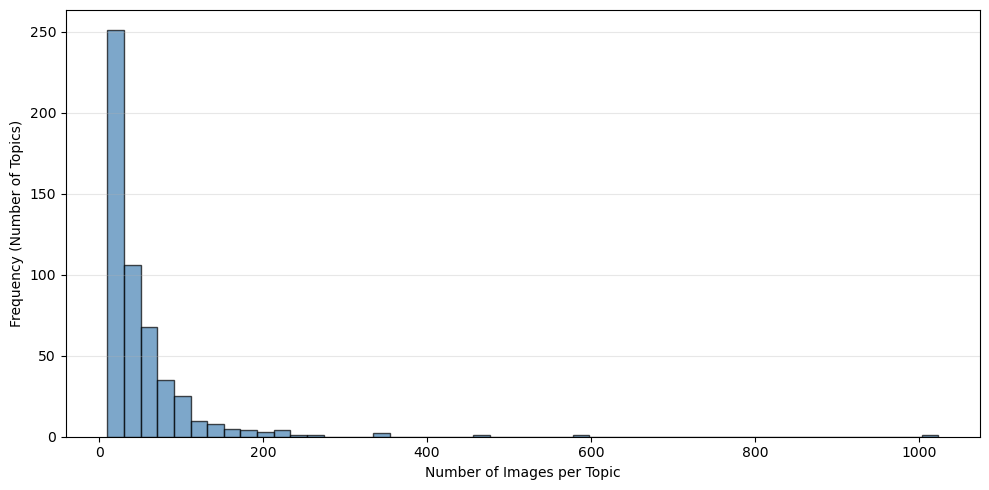

Total images: 35,368
Noise cluster (Topic -1): 8,396 (23.7%)
Meaningful topics: 526
Mean topic size: 51.3
Median topic size: 32


In [ ]:
# Figure 1: Distribution of Images Across Topics

topic_counts = results_df['Topic'].value_counts().sort_index()
topic_counts_no_noise = topic_counts[topic_counts.index != -1]

plt.figure(figsize=(10, 5))
plt.hist(topic_counts_no_noise.values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Images per Topic')
plt.ylabel('Frequency (Number of Topics)')
plt.title('Distribution of Images Across Topics')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
noise_count = topic_counts.get(-1, 0)
print(f"Total images: {len(results_df):,}")
print(f"Noise cluster (Topic -1): {noise_count:,} ({100*noise_count/len(results_df):.1f}%)")
print(f"Meaningful topics: {len(topic_counts_no_noise)}")
print(f"Mean topic size: {topic_counts_no_noise.mean():.1f}")
print(f"Median topic size: {topic_counts_no_noise.median():.0f}")

[Figure 1](#anchor-figure-topic-distribution-*) shows a right-skewed distribution, with most topics containing few photographs and a small number of large topics dominating.

Approximately half of the non-noise images are concentrated across roughly 80 topics, with the top 20 topics encompassing 5,840 images, representing 21.7 percent of the classified photographs. The subjects that attract the most visual focus (such as government offices, military formations, and formal meetings) are precisely aligned with themes of institutional authority and masculinity. This distribution suggests that the National Photo Company systematically prioritized certain subjects over others, rather than providing a comprehensive documentation of life in Washington.

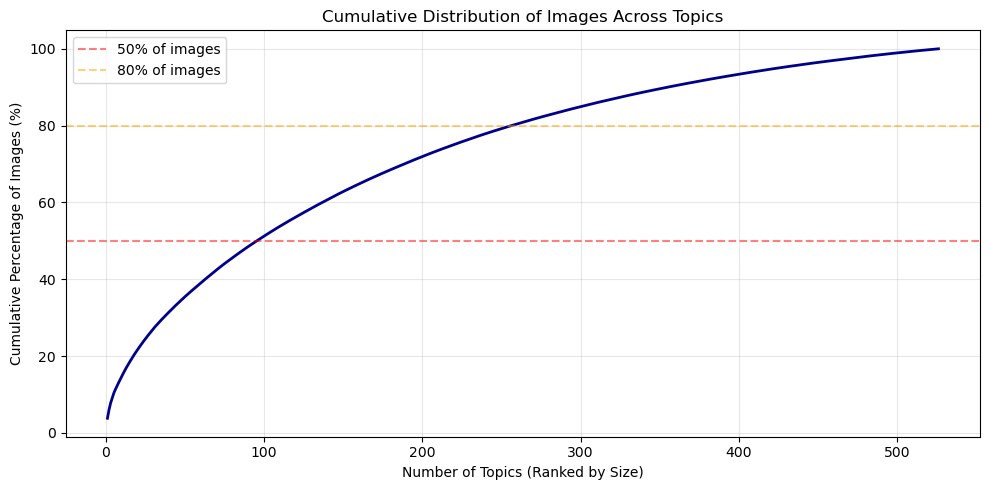

50% of images contained in top 96 topics
80% of images contained in top 257 topics


In [8]:
# Figure 2: Cumulative distribution

sorted_counts = topic_counts_no_noise.sort_values(ascending=False)
cumulative = np.cumsum(sorted_counts.values)
cumulative_pct = (cumulative / cumulative[-1]) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_pct) + 1), cumulative_pct, linewidth=2, color='darkblue')
plt.xlabel('Number of Topics (Ranked by Size)')
plt.ylabel('Cumulative Percentage of Images (%)')
plt.title('Cumulative Distribution of Images Across Topics')
plt.grid(True, alpha=0.3)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% of images')
plt.axhline(y=80, color='orange', linestyle='--', alpha=0.5, label='80% of images')
plt.legend()
plt.tight_layout()
plt.show()

# Find concentration
topics_for_50 = np.searchsorted(cumulative_pct, 50) + 1
topics_for_80 = np.searchsorted(cumulative_pct, 80) + 1
print(f"50% of images contained in top {topics_for_50} topics")
print(f"80% of images contained in top {topics_for_80} topics")

The curve in [Figure 2](#anchor-figure-cumulative-distribution-*) shows that a small number of large topics make up a disproportionate share of all classified photographs.*

The extended range of smaller topics illustrates the collection's diversity beyond institutional authority. Beneath the principal categories, hundreds of more specialized subjects examine particular landmarks, specific types of ceremonies, individual sporting events, or distinctive photographic moments.

### Patterns of Visual Emphasis

An analysis of the content within individual topics reveals distinct tendencies of visual focus. The top ten topics are delineated in Table 1, demonstrating consistent themes predominantly centered on governmental authority and civic life.

*Table 1: Top 10 topics by image count with representative keywords*

| Rank | Topic ID | Image Count | Percentage | Representative Keywords |
|------|----------|-------------|------------|-------------------------|
| 1 | 0 | 1,024 | 2.90% | pen, telephone, supplies, cluttered, writing |
| 2 | 1 | 598 | 1.69% | rifles, tent, rifle, caps, stretcher |
| 3 | 2 | 470 | 1.33% | meeting, conference, discussion, documents, signing |
| 4 | 3 | 353 | 1.00% | glove, action, throwing, pitch, leg |
| 5 | 4 | 337 | 0.95% | younger, older, faces, expressions, cigarette |
| 6 | 5 | 261 | 0.74% | yard, shutters, driveway, chimney, manicured |
| 7 | 6 | 238 | 0.67% | sliding, home, batter, catch, crouched |
| 8 | 7 | 232 | 0.66% | signing, map, document, coming, lockers |
| 9 | 8 | 225 | 0.64% | doormat, apples, younger, glass, argyle |
| 10 | 9 | 222 | 0.63% | pedimented, facade, domes, pediment, levels |

Four broad subject categories emerge from these clusters. Firstly, official government activities dominate, encompassing topics related to bureaucratic work (Topic 0), formal meetings (Topic 2), and document signing (Topic 7). Secondly, military subjects (Topic 1) attract considerable attention, reflecting Washington's role in national defense during and after the First World War. Thirdly, leisure and sports, particularly baseball (Topics 3 and 6), depict masculine recreation. Fourthly, architectural and domestic themes (Topics 5 and 9) illustrate Washington's built environment.

### Reading the Visual Conventions

The subsequent case studies analyse four subjects in greater depth: several prominent clusters, including Topics 0, 1, and 2, which garnered the most enduring photographic focus, and Topic 5, which records Washington's built environment. This subject links the collection's human subjects to the physical spaces they occupied. Each case study features the nine photographs whose embeddings are closest to the centroid of each topic, exemplifying the most representative samples of each theme. Again, it is important to note that the topic modeling algorithm does not see the images after the vision model captions them. 

**Professional Authority (Topic 0)**

The most prominent theme, Topic 0, centers on office environments defined by keywords such as "pen," "telephone," and "supplies." This cluster consists of portraits of officials seated at their desks. In this genre, authority is not derived from personal charisma or individual identity, but from the subject's position amidst the material tools of administration. By placing sitters behind desks and surrounding them with the active accoutrements of labor, the National Photo Company transformed the bureaucratic workspace into a stage for displaying professional expertise. 

The visual of the desk portrait was anchored by a specific orchestration of material props that signaled the official's command over the modern state's informational networks. The desk served as a modular stage that allowed the agency to present a variety of officials through a single, authoritative lens. This consistency transformed individual bureaucrats into interchangeable representatives of a larger institutional machine. In other words, rather than capturing a unique moment, each photograph reinforced a standardised visual grammar that prioritized the stability and continuity of the office over the specific personality of the individual official seated within it.

This standardization aligned with the Progressive Era press's preference for an aesthetic of mechanical objectivity where the camera was perceived as a neutral observer of institutional facts rather than a tool of interpretation. By emphasizing order and clerical diligence, these images framed the rapid expansion of federal power as the inevitable outcome of professional management.

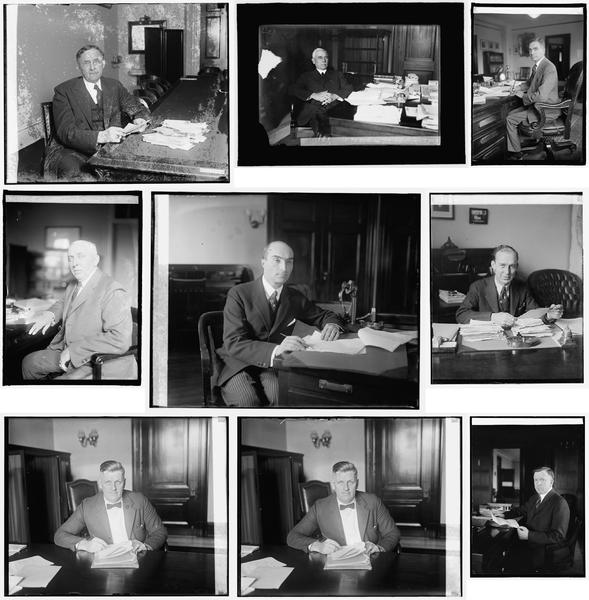

Topic 0 — 1024 images
Keywords: pen, telephone, supplies, cluttered, writing


In [9]:
# Figure 3: Topic 0 representative images
# These composites were pre-generated by BERTopic's VisualRepresentation

display(Image(filename=FIGURES_DIR / "topic_images" / "0.jpg", width=700))
print(f"Topic 0 — {topic_counts.get(0, 'N/A')} images")
print(f"Keywords: {get_topic_keywords(0, topics_data)}")

[Figure 3](#anchor-figure-representative-images-*): The nine most representative photographs from this cluster illustrate the standardised visual language of desk portraits.

**Military Power (Topic 1)**

The second-largest cluster focuses on military themes, defined by keywords such as "rifles," "tent," "caps," and "stretcher." These images depict personnel engaged in training, ceremonial formations, and official events that reflected Washington's role as the command center for American military operations during and after the First World War. Like Topic 0, these photographs of military personnel, equipment, and ceremonies participated in the visual legitimation of state power and military authority. The cluster captures a period of unprecedented military expansion in Washington, as the federal government mobilized resources for war and then maintained a significant peacetime military establishment through the 1920s.

The captions generated for Topic 1 reveal a consistent visual vocabulary emphasizing collective order over individual action. Image after image describes "men in military uniforms standing in a line," "groups of men in a field," and personnel arranged in "formations" before government buildings. References to uniforms predominate, with caps, helmets, and formal attire appearing repeatedly in the machine-generated descriptions. The presence of rifles appears frequently, though always in contexts of display rather than use, held by soldiers standing at attention or carried during parade formations. This emphasis on the material signifiers of military identity, the uniform, the weapon held correctly, the aligned formation, transformed potentially chaotic scenes of military activity into orderly visual narratives of disciplined power.

Put more simply, this visual consistency worked to naturalize what Michael Griffin, analysing twentieth-century wartime media coverage, terms a "sanitized" version of military imagery, one that emphasized organizational efficiency and preparedness while omitting any suggestion of violence or disorder (Griffin 2010). Griffin identifies such imagery as "backstage" photographs, non-combat images of troops and weaponry that dominated war coverage. While Griffin developed these concepts for wartime media relations, the visual vocabulary translates readily to peacetime contexts. The National Photo Company's military photographs operate in this same register: they depict the military as an institution of procedural order rather than an instrument of violence, presenting formations, ceremonies, and inspections rather than combat or its consequences.

The cluster also reveals the logistical infrastructure of military presence in Washington. Tents appear frequently in the captions, documenting the temporary encampments that accompanied military mobilization. These images of canvas shelters, grassy fields, and assembled equipment recorded the material conditions of military life while simultaneously aestheticizing them. A photograph of soldiers before their tents, arranged symmetrically with equipment visible, transformed the mundane realities of camp life into a visual demonstration of military preparedness. American flags appear throughout the cluster, marking these spaces as sites of national significance and connecting the specific activities depicted to broader patriotic narratives that newspaper editors and their readers would immediately recognize.

What the cluster excludes proves as revealing as what it contains. The military photographs overwhelmingly depict scenes of preparation, display, and ceremony rather than the realities of combat or its aftermath. While the collection spans the First World War and its immediate aftermath, no images document wounded soldiers, battlefield destruction, or the human costs of military operations. This absence reflects the commercial constraints under which Herbert French's photographers operated. Newspapers and magazines sought images that could be printed without disturbing readers, that would inspire confidence in military competence rather than questions about the costs of war. The resulting archive established a template for media-military visual relations that prioritized the performance of order, a template that would shape how Americans visualized their military institutions for decades to come.


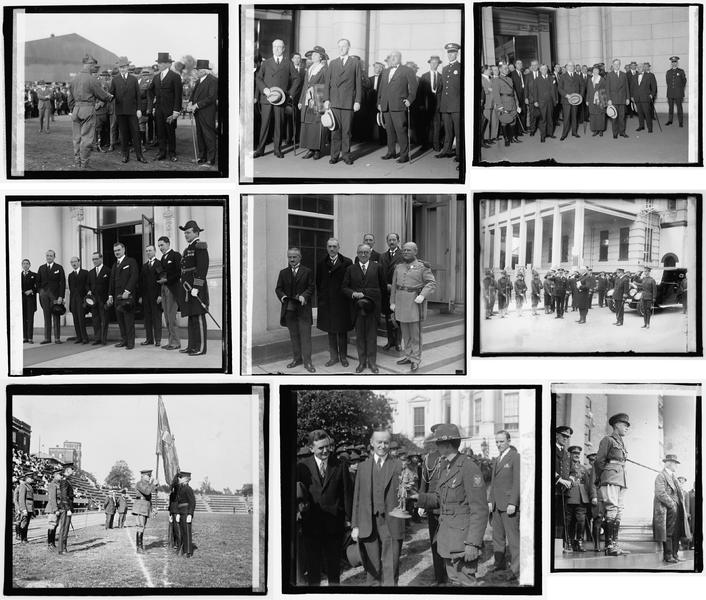

Topic 1 — 598 images
Keywords: rifles, tent, rifle, caps, stretcher


In [10]:
# Figure 4: Topic 1 representative images
display(Image(filename=FIGURES_DIR / "topic_images" / "1.jpg", width=700))
print(f"Topic 1 — {topic_counts.get(1, 'N/A')} images")
print(f"Keywords: {get_topic_keywords(1, topics_data)}")

*Figure 4: Representative images from Topic 1 (Military Power). These photographs depict military personnel in formal formations and official functions.*

**Official Governance (Topic 2)**

Topic 2 comprises 470 photographs centered on formal meetings and official proceedings. The cluster's defining keywords include "meeting," "conference," "discussion," "documents," "signing," and "chandeliers," capturing scenes of collective deliberation rather than individual authority. Where Topic 0 isolated bureaucrats at their desks, this cluster frames governance as a social act performed around conference tables. The captions consistently describe men "engaged in serious conversation" with documents "scattered" before them, suggesting that the camera's role was to witness the moment of decision rather than the person who made it. This shift from individual to group portraiture reflects the practical demands of the news industry, which required images showing that something had happened rather than simply who held office. A photograph of a committee in session could accompany a headline about policy debates in ways that a solitary desk portrait could not. The compositional emphasis on the assembled group, with participants arranged symmetrically around a central table, transformed potentially chaotic deliberations into orderly visual narratives of procedural democracy.

Many of these photographs document international events, including the signing of the British War Loan in 1917, the French War Loan of the same year, and sessions with the Czechoslovakia and American Debt Commission in 1925. The cluster also contains images from congressional investigations, with the Teapot Dome hearings, steel strike testimonies, and immigration committee sessions all represented among the 470 photographs. The captions describe "men dressed in formal attire" arranged around tables with "large maps hanging on the wall," capturing Washington's position as a hub of postwar diplomacy and domestic oversight. These images served multiple audiences simultaneously. Domestic newspapers sought evidence of American engagement on the world stage while foreign press services required visual proof that agreements had been formalized. Congressional committees similarly needed photographic documentation that could be distributed to regional papers demonstrating that legislators were actively investigating matters of public concern. The National Photo Company's coverage of these events transformed abstract processes of negotiation and inquiry into concrete visual records that could circulate through the nation's print media networks.

The recurring presence of documents and signing implements in these photographs suggests an interest in the physical ritual of agreement. Captions note men "holding a piece of paper," "signing a document with a pen," or standing before tables "covered with papers and documents." The act of putting pen to paper, captured at the precise moment of commitment, transformed abstract diplomatic negotiations into concrete visual evidence. This emphasis on the material trace of agreement reflects what Vilém Flusser identified as photography's capacity to make invisible processes visible (Flusser 1983). The document being signed became proof that governance had occurred. What distinguishes these images from the desk portraits of Topic 0 is their focus on transaction rather than position. The desk portrait presented an official's ongoing authority; the signing photograph captured a specific act with before and after states. This temporal dimension gave the images particular value for newspapers covering breaking developments, as they could demonstrate not just who was involved but that a binding decision had been reached. The ornate settings visible in the keyword "chandeliers" reinforced the significance of these moments, situating routine procedural acts within spaces designed to project historical weight.


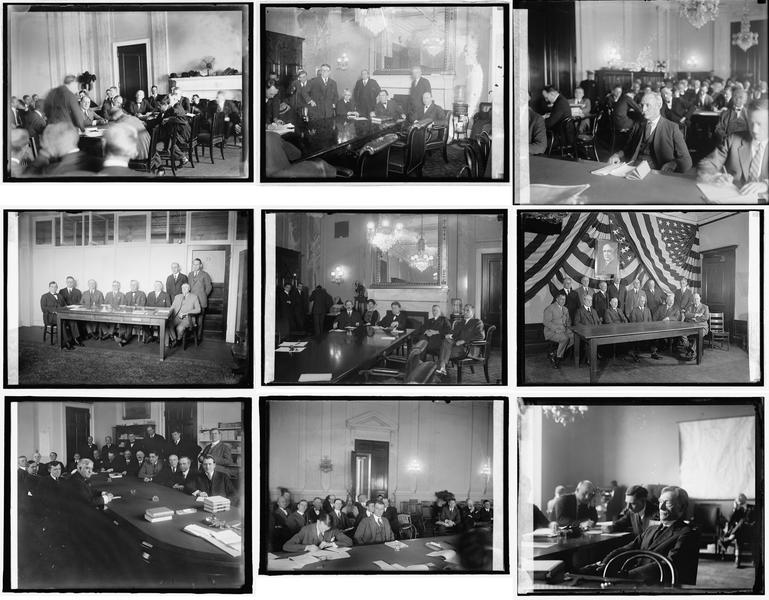

Topic 2 — 470 images
Keywords: meeting, conference, discussion, documents, signing


In [11]:
# Figure 5: Topic 2 representative images
display(Image(filename=FIGURES_DIR / "topic_images" / "2.jpg", width=700))
print(f"Topic 2 — {topic_counts.get(2, 'N/A')} images")
print(f"Keywords: {get_topic_keywords(2, topics_data)}")

*Figure 5: Representative images from Topic 2 (Official Governance). Formal meetings, treaty signings, and committee proceedings characterize this cluster.*

**Washington's Built Environment (Topic 5)**

Beyond individual figures, the collection systematically recorded Washington's residential landscape. Topic 5, defined by keywords like "yard," "shutters," "driveway," and "manicured," captures domestic exteriors that reflect the city's housing inventory. As Claire Zimmerman notes, architectural photography in this period increasingly served commercial marketing functions alongside documentation (Zimmerman 2014). Similar to the most populated topics, the standardised framing of these houses (centered, symmetrical, and clear of clutter) reflects a desire to present the built environment as a site of order and respectability.

The captions generated for Topic 5 reveal a remarkably consistent visual vocabulary. House after house appears as a "two-story brick" structure with a "large front porch," "sloping roof," and "chimney." Properties are "surrounded by trees and shrubs" with "driveways leading up" to their entrances. This uniformity suggests that the National Photo Company developed standardized conventions for residential documentation, positioning cameras at consistent distances and angles to maximize the impression of substantial, well-maintained properties. The resulting images functioned less as architectural records than as visual testimonials to respectable living, the kind of photographs that real estate agents might use to market properties or that homeowners might commission to document their achieved status.

By extending the legitimating visual grammar to private neighborhoods, the archive connects D.C.'s human subjects to the physical spaces they occupied. The orderly domesticity captured in Topic 5 represents the residential manifestation of the Progressive Era's broader urban vision. As Margaret Farrar argues, the architecture and design of a capital city serve to "create citizens," legitimizing some groups while rendering others "out of place" (Farrar 2008). The homes photographed in this cluster embody the aspirational ideal of citizen-homeownership that Progressive reformers championed as the foundation of democratic stability. A citizen who owned a well-maintained property with a front lawn and a porch had a literal stake in the civic order that the government buildings in Topic 0 represented.

What the cluster excludes proves as revealing as what it contains. The residential photographs overwhelmingly depict single-family homes with private yards, while Washington's alley dwellings and tenement blocks, which housed thousands of the city's working-class and African American residents, appear nowhere in the collection's domestic imagery. This selective documentation aligned with the priorities of Progressive Era housing reformers who characterized alley dwellings as breeding grounds for disease and moral degradation. Commercial clients seeking property documentation wanted images of marketable respectability, not documentary evidence of substandard housing that reformers were simultaneously campaigning to demolish.

The consistency of Topic 5's visual conventions also reflects the practical circumstances of commercial photography. Herbert French's photographers likely received commissions from real estate developers, mortgage companies, and individual homeowners who specified the kind of presentation they expected. Such clients would have rejected images that showed peeling paint, unmaintained yards, or neighboring properties in poor condition. Over time, these commercial expectations produced a repertoire of compositional solutions that photographers applied routinely, such as centering the house in frame, including enough of the yard to suggest spaciousness, and capturing the property in favorable light that emphasized architectural details. The archive's residential photographs thus document not simply what Washington's housing looked like but what paying clients wanted it to look like.

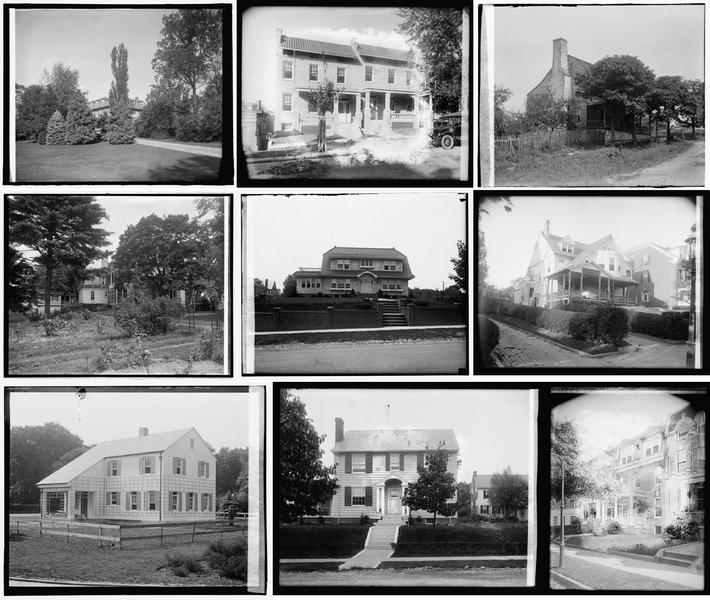

Topic 5 — 261 images
Keywords: yard, shutters, driveway, chimney, manicured


In [12]:
# Figure 6: Topic 5 representative images
display(Image(filename=FIGURES_DIR / "topic_images" / "5.jpg", width=700))
print(f"Topic 5 — {topic_counts.get(5, 'N/A')} images")
print(f"Keywords: {get_topic_keywords(5, topics_data)}")

*Figure 6: Representative images from Topic 5 (Washington's Built Environment). Standardised documentation of residential architecture across the capital.*

### Who Was Seen, Who Was Silenced

The thematic clusters discussed above share a common feature: they depict spaces where women were systematically excluded in early twentieth-century society. Across all generated captions, male-gendered terms (man, men, he, his) outnumber female-gendered terms (woman, women, she, her) by nearly 4 to 1 (3.69:1). Within the main institutional topics, this imbalance becomes even more noticeable.

These numbers highlight the gendered structure of the collection's focus, revealing systematic biases that go beyond individual editorial choices. The disparity emerged from the convergence of multiple factors operating simultaneously. Herbert French's photographers followed their clients' assignments, clients requested subjects that would interest their audiences, and audiences had been conditioned to associate public authority with male figures. While individuals in this chain may not have necessarily intended to exclude women, the cumulative effect was a visual archive in which female presence became exceptional rather than ordinary. 

This pattern exemplifies what George Gerbner termed "symbolic annihilation," the systematic underrepresentation of marginalized groups that renders them invisible within the public visual record (Gerbner 1972; Tuchman 1978). The timing matters here. The collection spans the final push for women's suffrage, the ratification of the Nineteenth Amendment in 1920, and the decade following. One might expect photographs to reflect women's expanded civic presence after 1920, yet the algorithmic analysis reveals remarkable consistency in male dominance across the collection's entire timeframe. 

The way gender hierarchies are visually constructed also connects with race, although the algorithmic approach reveals these dynamics in a different way. The archive's documentation of events like the 1925 and 1926 Ku Klux Klan parades in Washington shows how commercial photography could make hate groups seem normal within public life. Furthermore, the collection's strong focus on institutional spaces, such as government buildings, military sites, and official gatherings, records locations that were either officially or unofficially segregated during Washington's Jim Crow era.

The archive largely omits documentation of African American community life in early twentieth-century Washington. The few images that do explicitly identify African American subjects consistently depict Black Washingtonians in service and labor roles, such as a nursemaid in a park and men shoveling snow and paving roads. The only photograph connected to Howard University shows President Calvin Coolidge speaking at a graduation ceremony, documenting a white visitor rather than the institution's community. Entirely absent are the vibrant institutions that defined Black Washington during this period, such as the businesses along U Street, the intellectual life of Howard, or the civic organizations that were shaping African American political mobilization.

This gap in representation was not incidental. The National Photo Company's clients, primarily newspapers, magazines, and government agencies, operated within a segregated media system that determined which subjects warranted photographic documentation. The commercial priorities of Progressive Era photojournalism thus produced an archive that rendered African American civic life virtually invisible even as it recorded the public presence of those who opposed Black political participation. 

In [13]:
# Gender analysis: count gendered terms in captions

male_terms = r"\b(man|men|he|his|him|boy|boys|male|gentleman|gentlemen)\b"
female_terms = r"\b(woman|women|she|her|hers|girl|girls|female|lady|ladies)\b"

def count_matches(text, pattern):
    return len(re.findall(pattern, str(text).lower()))

captions_df["male_count"] = captions_df["caption"].apply(lambda x: count_matches(x, male_terms))
captions_df["female_count"] = captions_df["caption"].apply(lambda x: count_matches(x, female_terms))

total_male = captions_df["male_count"].sum()
total_female = captions_df["female_count"].sum()
ratio = total_male / total_female if total_female > 0 else float('inf')

# Presence in captions
has_male = (captions_df["male_count"] > 0).sum()
has_female = (captions_df["female_count"] > 0).sum()
male_only = ((captions_df["male_count"] > 0) & (captions_df["female_count"] == 0)).sum()

print("=== Gender Term Analysis ===")
print(f"Male term mentions: {total_male:,}")
print(f"Female term mentions: {total_female:,}")
print(f"Ratio: {ratio:.2f}:1")
print(f"\nCaptions mentioning men: {has_male:,} ({100*has_male/len(captions_df):.1f}%)")
print(f"Captions mentioning women: {has_female:,} ({100*has_female/len(captions_df):.1f}%)")
print(f"Captions with men only: {male_only:,} ({100*male_only/len(captions_df):.1f}%)")

=== Gender Term Analysis ===
Male term mentions: 108,127
Female term mentions: 27,583
Ratio: 3.92:1

Captions mentioning men: 22,603 (63.9%)
Captions mentioning women: 7,068 (20.0%)
Captions with men only: 18,881 (53.4%)


### What Resists Classification

The structures of institutional power and gender disparity discussed earlier shape the photographs that form distinct topical groups; however, 23.7 percent of the images (8,396 photos) were placed in the noise cluster. Unlike traditional cataloging that forces every item into fixed categories, HDBSCAN detects photos that do not fit dominant trends making evident the diversity and irregularity in large visual collections.

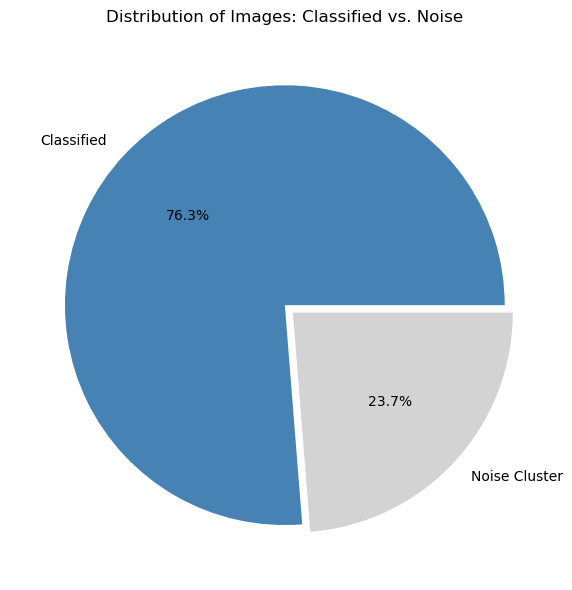

Classified images: 26,972 (76.3%)
Noise cluster: 8,396 (23.7%)


In [14]:
# Figure 7: Distribution of noise vs classified images
noise_count = topic_counts.get(-1, 0)
classified_count = len(results_df) - noise_count

plt.figure(figsize=(6, 6))
plt.pie([classified_count, noise_count], 
        labels=['Classified', 'Noise Cluster'], 
        autopct='%1.1f%%',
        colors=['steelblue', 'lightgray'],
        explode=[0, 0.05])
plt.title('Distribution of Images: Classified vs. Noise')
plt.tight_layout()
plt.show()

print(f"Classified images: {classified_count:,} ({100*classified_count/len(results_df):.1f}%)")
print(f"Noise cluster: {noise_count:,} ({100*noise_count/len(results_df):.1f}%)")

*Figure 7: Distribution of images between meaningful topics and the noise cluster. Nearly a quarter of all photographs resist topical categorisation.*

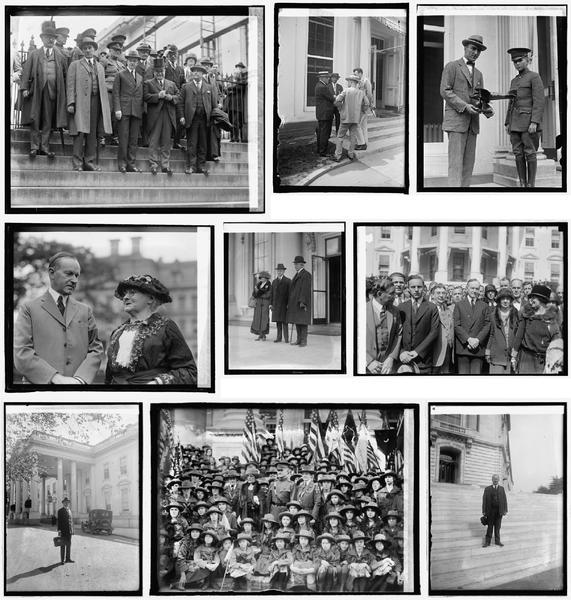

Noise Cluster (Topic -1) — 8396 images
Keywords: theater, theatre, courtyard, wreath, robes


In [15]:
# Figure 8: Noise cluster representative images
display(Image(filename=FIGURES_DIR / "topic_images" / "-1.jpg", width=700))
print(f"Noise Cluster (Topic -1) — {noise_count} images")
print(f"Keywords: {get_topic_keywords(-1, topics_data)}")

*Figure 8: Representative images from the Noise Cluster (Topic -1). These photographs resist topical categorisation, demonstrating the diversity of content that falls outside the collection's dominant visual logics.*

Notably, the noise cluster may include precisely those photographs that oppose the primary visual themes of the collection, images whose meanings are heavily dependent on context or too unique to be captured through automated clustering. Several examples demonstrate this diversity. A photograph captioned "Mrs. Geo. Oakley Totten" shows "a woman sitting at a table with a sculpture of a ballerina in front of her... holding a paintbrush and appears to be in the process of painting the sculpture." This is an artistic domestic scene that goes beyond the collection's usual themes of institutional masculinity. Another image, simply captioned "Children," displays "a group of children and a man standing in front of a building... of different ages and ethnicities," thus subject challenges the conventions of formal portraiture common in most topics.

Therefore, researchers should view the noise cluster not just as leftover data but as an important category that defines the limits of automated subject organization.

# What the Method Cannot See

It is important to consider the findings of this study alongside four broad limitations that affect both the historical claims and the methodological contributions: caption accuracy, the inherent limitations of visual-textual translation, layered biases in the source material, and collection scope.

The first limitation involves caption accuracy. As noted before, Florence-2 performs well with modern photographs but may struggle with historical images. Unfamiliar objects, period-specific clothing, and damaged negatives can lead to inaccurate descriptions. Sometimes, misidentifications may also happen, such as a photo labeled "First National Bank of So. Md. Marlborough" (LCCN2016826472), which results in a caption saying the sign reads "Bank of America", which didn't operate under that name until 1998 (Figure 9). A study of sample photographs confirmed that Florence-2 generally produces reasonable descriptions of overall scene composition, though a comprehensive evaluation of caption accuracy against ground truth annotations across the entire corpus was not conducted. Consequently, some topic clusters may reflect model errors rather than actual visual features.

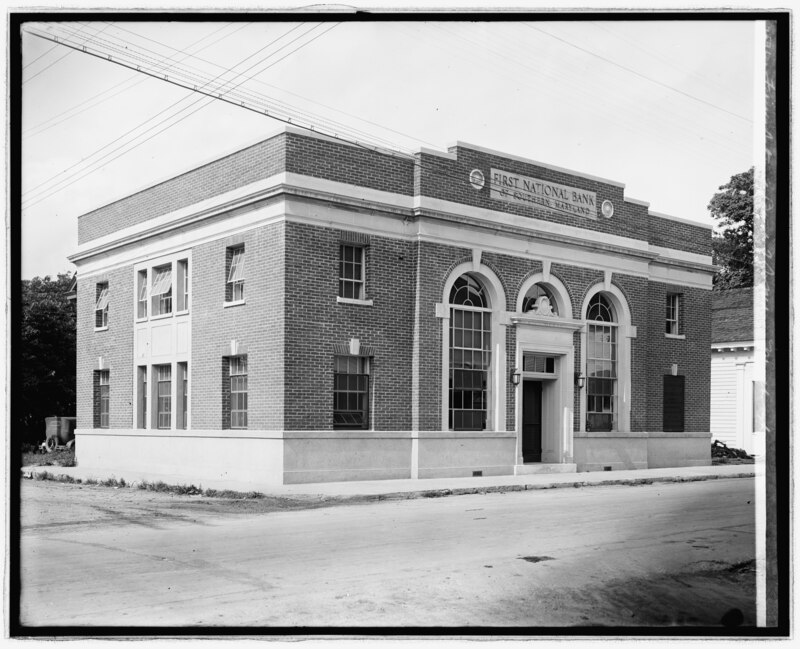

Figure 9: First National Bank of So. Md. Marlborough (LCCN2016826472).
Florence-2 incorrectly identifies the signage as 'Bank of America.'


In [16]:
# Figure 9: Caption accuracy limitation example
display(Image(filename=FIGURES_DIR / "first_national_bank_caption_error.jpg", width=500))
print("Figure 9: First National Bank of So. Md. Marlborough (LCCN2016826472).")
print("Florence-2 incorrectly identifies the signage as 'Bank of America.'")

*Figure 9: First National Bank of So. Md. Marlborough (LCCN2016826472). Florence-2 incorrectly identifies the signage as "Bank of America," demonstrating how vision-language models struggle with historical images containing period-specific text and unfamiliar institutional names.*

The second limitation relates to visual-textual translation itself. While the method detailed here is able to better capture semantic information than techniques that rely on only extracting low-level features, no automated method can capture aspects of meaning that defy verbal description. Photographs convey emotional responses, artistic arrangements of elements, and the physical sensation of viewing an image that go beyond what natural language captions can express. For instance, a photograph might evoke a sense of awe or unease through its lighting and shadows, or create a feeling of intimacy through its framing, but these affective dimensions are difficult to translate. Thus, this method may still miss the broader interpretive layers that historians might draw from contextual knowledge or visual literacy. 

The third limitation involves layered biases. Multiple levels of bias influence both the source material and the algorithmic analysis. As Amanda Wasielewski warns, "the great fallacy of quantitative research is usually not the method itself, but rather the belief in the purity of the data and its lack of bias. Counting a biased sample reproduces that bias" (Wasielewski 2023, p. 79). The original National Photo Company collection reflects the commercial priorities and social perspectives of Herbert E. French and his photographers, who focused on subjects that would sell newspapers and appeal to their audience. This creates an initial bias toward certain types of images. Additionally, the digitization process by the Library of Congress may have prioritized certain materials that don't fully capture large commercial priorities for the agency.

A fourth limitation concerns collection scope. The noise cluster analysis revealed an unexpected finding: a photograph of concentration camp uniforms (LCCN90709928) that clearly postdates the National Photo Company's operations from 1909 to 1932. While the collection contains numerous photographs relating to Germany from the World War I era, this concentration camp image dates from the Nazi period, well after the company ceased operations. The image was likely part of Herbert French's personal collection, acquired by the Library of Congress alongside his commercial archive. Its isolation as the sole post-1932 German photograph suggests an anomalous inclusion rather than systematic collecting beyond the company's active years (Figure 10). This discovery suggests that the "National Photo Company Collection" as presented through the Library of Congress interface may not represent a unified corpus but rather an aggregation of materials with complex and sometimes opaque provenance histories. While such anomalies do not invalidate the overall analysis (the concentration camp photograph was correctly identified as noise and excluded from topic modeling), researchers working with institutional collections should remain attentive to the possibility that named collections may contain materials beyond their stated scope.

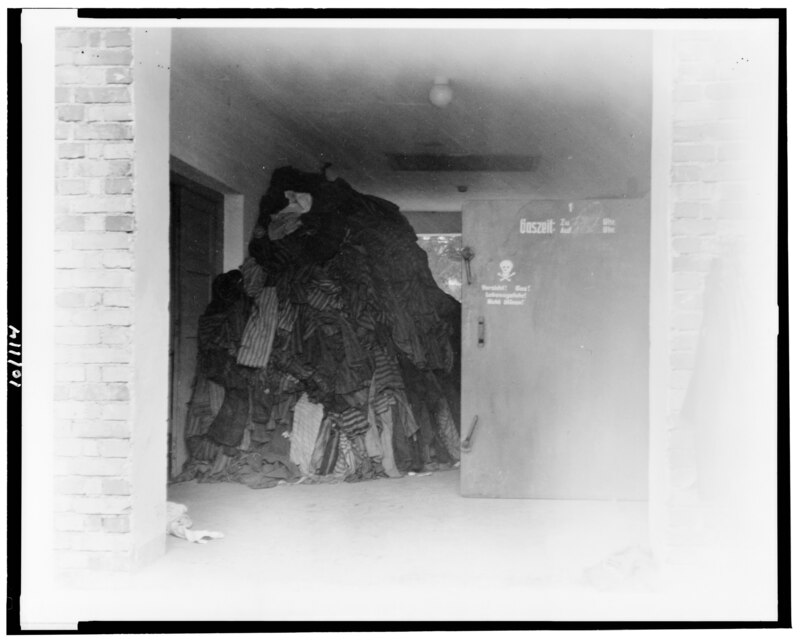

Figure 10: Concentration camp uniforms (LCCN90709928).
This photograph postdates the National Photo Company's operations.


In [17]:
# Figure 10: Archival provenance limitation example
display(Image(filename=FIGURES_DIR / "concentration_camp_provenance.jpg", width=500))
print("Figure 10: Concentration camp uniforms (LCCN90709928).")
print("This photograph postdates the National Photo Company's operations.")

*Figure 10: Concentration camp uniforms (LCCN90709928). This photograph, which clearly postdates the National Photo Company's operations (1909-1932), was found within the collection's noise cluster. Its presence demonstrates how computational methods can reveal archival provenance complications invisible through traditional interfaces.*

## Conclusion

Overall, this study shows how algorithmic methods can uncover visual representation trends that are hard to identify through traditional archival research alone. Analyzing 35,368 photographs revealed 527 distinct subject clusters, a nearly four-to-one male-to-female term ratio, and a 23.7 percent noise cluster. This quantitative data offers new insights into how commercial photography influenced visual authority during the Progressive Era in Washington. These findings suggest that the National Photo Company acted as a "visual infrastructure of state legitimation" that made governmental authority appear natural, orderly, and inevitable by repeatedly using specific compositional conventions.

The clear gender disparities highlight patterns that scholars in the field of visual culture have long studied, yet rarely measured on a large scale. The nearly four-to-one overall ratio of male to female references (3.69:1), which rises to over one thousand to one in discussions about institutions, demonstrates Gaye Tuchman's concept of "symbolic annihilation" (Tuchman 1978). The dearth of African American subjects in the collection similarly reflects what George Gerbner termed the "absence" of marginalized groups from media representation (Gerbner 1972).


Methodologically, this study presents a reproducible pipeline that links visual archives with established text analysis techniques. Combining vision-language captioning with neural topic modeling enables researchers to examine visual collections using familiar digital humanities methods. Furthermore, the deterministic settings ensure that results can be verified and lays a foundation for scholarly discussion about both the methods and their outcomes.

The explicit documentation of the noise cluster (the 23.7 percent of photographs that resisted topical categorization) frames algorithmic classification as a complement rather than a replacement for traditional historical methods. By recognizing what defies categorization instead of forcing every image into predefined topics, this approach creates starting points for humanistic inquiry rather than claiming definitive classifications. As Taylor Arnold and Lauren Tilton argue, computational methods work "not at the expense of close viewing. In combination with subject matter expertise and subsequent close analyses... [they allow] scholars to ask and address new and existing questions" (Arnold & Tilton 2019). The topics identified here serve as tentative maps, encouraging historians to examine representative images, evaluate cluster coherence, and use algorithmic groupings as entry points for deeper archival exploration.

## Future Directions

The strengths and limitations discussed above point to several promising directions for future research. First, the methodology developed here could be applied to other collections. Comparing these collections would determine whether the patterns identified, such as the focus on institutional authority and the marginalization of women and minorities, are unique to Herbert E. French's work or reflect broader trends in early twentieth-century American commercial photography.

Second, for historians looking to use these findings, the topics can serve as curated subsets suitable for focused research. A historian studying women's representation in Progressive Era Washington might examine the 20 percent of captions that mention women to identify which specific topics include female subjects and the contexts where they appear. A researcher interested in military visual culture could analyse Topic 1's 598 photographs as a defined set for detailed study of uniform styles, rank insignia, and compositional patterns.

Finally, the noise cluster itself also deserves further study. The 8,396 photographs that resisted topical classification may feature subjects and visual styles that fall outside mainstream commercial standards and are exactly the types of images that could complicate or challenge the main patterns identified in this research.

## References

Arnold, T., & Tilton, L. (2019). Distant viewing: Analyzing large visual corpora. *Digital Scholarship in the Humanities*, 34(Supplement_1), i3–i16. https://doi.org/10.1093/llc/fqz013

Arnold, T., & Tilton, L. (2022). *Access & Discovery of Documentary Images (ADDI)*. Library of Congress Labs. https://distant-viewing.github.io/addi/

Arnold, T., & Tilton, L. (2024). *Explainable Search and Discovery of Visual Cultural Heritage Collections with Multimodal Large Language Models*. arXiv preprint. https://doi.org/10.48550/arXiv.2411.04663

Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet Allocation. *Journal of Machine Learning Research*, 3, 993–1022.

Bourdieu, P. (1990). *Photography: A Middle-brow Art*. Stanford University Press.

Brown, E. H. (2005). *The Corporate Eye: Photography and the Rationalization of American Commercial Culture, 1884–1929*. Johns Hopkins University Press.

Carmichael, J. (2018). *First World War Photographers*. Routledge.

Cheles, L., & Giacone, A. (Eds.). (2020). *The Political Portrait: Leadership, Image and Power*. Routledge.

Cohen, M. (1999). *The Sentimental Education of the Novel*. Princeton University Press.

Crawford, K., & Paglen, T. (2019). Excavating AI: The Politics of Training Sets for Machine Learning. https://excavating.ai

Davison, J. (2010). [In]visible [in]tangibles: Visual portraits of the business élite. *Accounting, Organizations and Society*, 35(2), 165–183. https://doi.org/10.1016/j.aos.2009.03.003

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. In *Proceedings of NAACL-HLT 2019* (pp. 4171–4186).

Farrar, M. E. (2008). *Building the Body Politic: Power and Urban Space in Washington, D.C.* University of Illinois Press.

Flusser, V. (1983). *Towards a Philosophy of Photography*. Reaktion Books.

Gerbner, G. (1972). Violence in television drama: Trends and symbolic functions. In G. A. Comstock & E. A. Rubinstein (Eds.), *Television and social behavior. Vol. 1: Media content and control* (pp. 28–187). U.S. Government Printing Office.

Gervais, T., in collaboration with G. Morel. (2017). *The Making of Visual News: A History of Photography in the Press* (J. Tittenson, Trans.). Bloomsbury Academic.

Green, C. M. (1963). *Washington: Village and Capital, 1800–1878*. Princeton University Press.

Griffin, M. (2010). Media images of war. *Media, War & Conflict*, 3(1), 7–41. https://doi.org/10.1177/1750635210356813

Grootendorst, M. (2020). *KeyBERT: Minimal keyword extraction with BERT*. Zenodo. https://doi.org/10.5281/zenodo.4461265

Grootendorst, M. (2022). *BERTopic: Neural topic modeling with a class-based TF-IDF procedure*. arXiv preprint. https://doi.org/10.48550/arXiv.2203.05794

Guthey, E., & Jackson, B. (2005). CEO Portraits and the Authenticity Paradox. *Journal of Management Studies*, 42(5), 1057–1082. https://doi.org/10.1111/j.1467-6486.2005.00532.x

Hall, S. (Ed.). (1997). *Representation: Cultural Representations and Signifying Practices*. Sage.

Impett, L., & Offert, F. (2023). *There Is a Digital Art History*. arXiv preprint. https://doi.org/10.48550/arXiv.2308.07464

ImageMagick Studio LLC. (2024). *ImageMagick*. https://imagemagick.org

Library of Congress. (n.d.). *National Photo Company Collection*. https://www.loc.gov/pictures/collection/npco/

Library of Congress Research Guides. (n.d.). *National Photo Company Collection*. https://guides.loc.gov/american-women-prints-photographs/photojournalism/national-photo-co-collection

Lin, T.-Y., Maire, M., Belongie, S., Hays, J., Perona, P., Ramanan, D., Dollár, P., & Zitnick, C. L. (2014). Microsoft COCO: Common Objects in Context. In *Computer Vision – ECCV 2014* (pp. 740–755). Springer. https://doi.org/10.1007/978-3-319-10602-1_48

Lubin, D. M. (2015). *Flags and Faces: The Visual Culture of America's First World War*. University of California Press.

Manovich, L. (2012). How to Compare One Million Images. In *Software Takes Command*. Bloomsbury Academic.

Manovich, L. (2015). Data Science and Digital Art History. *International Journal of Digital Art History*, 1, 13–35.

Mari, W. (2021). *The American Newsroom: A History, 1920–1960*. University of Missouri Press.

Meeks, E., & Weingart, S. B. (2012). The Digital Humanities Contribution to Topic Modeling. *Journal of Digital Humanities*, 2(1). http://journalofdigitalhumanities.org/2-1/dh-contribution-to-topic-modeling/

Mitchell, W. J. T. (2005). There Are No Visual Media. *Journal of Visual Culture*, 4(2), 257–266.

Moretti, F. (2000). Conjectures on World Literature. *New Left Review*, 1, 54–68.

Natanson, B. O. (2007). Worth a Billion Words? Library of Congress Pictures Online. *Journal of American History*, 94(1), 99–111.

Nilsen, M. (2017). *Nineteenth-Century Photographs and Architecture: Documenting History, Charting Progress, and Exploring the World*. Routledge.

Peterson, J. A. (1985). The Nation's First Comprehensive City Plan. *Journal of the American Planning Association*, 51(2), 134–150.

Quagliati, N. (2021). Reframing American Military Power: The Visual Culture of World War I. *Journal of War and Culture Studies*, 14(3), 263–281.

Radford, A., et al. (2021). Learning Transferable Visual Models From Natural Language Supervision. In *Proceedings of ICML 2021*.

Reps, J. W. (1967). *Monumental Washington: The Planning and Development of the Capital Center*. Princeton University Press.

Robertson, S. E., & Zaragoza, H. (2009). The Probabilistic Relevance Framework: BM25 and Beyond. *Foundations and Trends in Information Retrieval*, 3(4), 333–389. https://doi.org/10.1561/1500000019

Russakovsky, O., Deng, J., Su, H., Krause, J., Satheesh, S., Ma, S., Huang, Z., Karpathy, A., Khosla, A., Bernstein, M., Berg, A., & Fei-Fei, L. (2015). ImageNet Large Scale Visual Recognition Challenge. *International Journal of Computer Vision*, 115(3), 211–252. https://doi.org/10.1007/s11263-015-0816-y

Sekula, A. (1986). The Body and the Archive. *October*, 39, 3–64.

Smeulders, A. W. M., Worring, M., Santini, S., Gupta, A., & Jain, R. (2000). Content-based image retrieval at the end of the early years. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 22(12), 1349–1380.

Solaroli, M. (2016). The Rules of a Middle-Brow Art: Digital Production and Cultural Consecration in the Global Field of Professional Photojournalism. *Poetics*, 59, 50–66.

Sontag, S. (1977). *On Photography*. Farrar, Straus and Giroux.

Tagg, J. (1988). *The Burden of Representation: Essays on Photographies and Histories*. Macmillan.

Thomas, J., & Testini, I. (2024). Captioning the Past: Searching the Content of Illustrations in Large Datasets. *Digital Humanities Quarterly*.

Tuchman, G. (1978). *Making News: A Study in the Construction of Reality*. Free Press.

van Noord, N. (2022). A Survey of Computational Methods for Iconic Image Analysis. *Digital Scholarship in the Humanities*, 37(4), 1316–1338.

Vowinckel, A. (2021). *Political Photography in the 20th Century*. Routledge.

Wang, W., Bao, H., Huang, S., Dong, L., & Wei, F. (2021). MiniLMv2: Multi-Head Self-Attention Relation Distillation for Compressing Pretrained Transformers. In *Findings of the Association for Computational Linguistics: ACL-IJCNLP 2021* (pp. 2140–2151). https://doi.org/10.48550/arXiv.2012.15828

Wasielewski, A. (2023). *Computational Formalism: Art History and Machine Learning*. MIT Press.

Wevers, M., & Smits, T. (2020). The visual digital turn: Using neural networks to study historical images. *Digital Scholarship in the Humanities*, 35(1), 194–207. https://doi.org/10.1093/llc/fqy085

Wikimedia Commons. (n.d.). *Category:National Photo Company Collection*. https://commons.wikimedia.org/wiki/Category:National_Photo_Company_Collection

Xiao, B., et al. (2024). Florence-2: Advancing a Unified Representation for a Variety of Vision Tasks. *arXiv preprint*. https://doi.org/10.48550/arXiv.2311.06242

Yotova, D. H. (2023). The Bain News Service: Commercial News Photography in the Progressive Era. *Photography & Culture*, 16(2), 189–211.

Zimmerman, C. (2014). *Photographic Architecture in the Twentieth Century*. University of Minnesota Press.